# RQ3: Given that a flight is delayed, can we predict the probability of cancellation for t minutes after the delay?

## Motivation
Flight delays are inevitable. With so many
sources of error and interdependent systems, there is no
getting around delays in flights. Once a delay has occured,
the next fear that goes through travellers’ minds is, ”will
my flight get cancelled?”. This can seriously alter the plans
of a traveller and cause issues for the airport and airlines
involved to compensate the passengers involved. For this
reason, we would like to investigate if we can find a prob-
ability distribution to predict how long after a flight has
been delayed, is expected to be cancelled, if at all. This
information could be shown to passengers on the delay
announcement to give them a constant, realistic idea about
how likely it is that their flight is cancelled, and allow them
to plan accordingly.
## Proposed Methodology
Using the dataset, we will first
perform rounds of cleaning. Once the data is clean, we will
start filtering and grouping cases where cancellations occur
and do not occur. From there, we can determine a duration
of delay before the flight is cancelled or takes off. With this
duration, we can perform a survival analysis (Kaplin-Meier,
Cox Proportional Hazard) to find the probability that the
event occurs given a time t after the delay was announced.
Further testing will be done afterwards, creating multiple
survival plots for various cases of indicators of cancellation
to increase accuracy. Combining these factors, we can have
an educated survival analysis plot based on the conditions
of the delay, which allows us to predict the likelihood that
the flight is cancelled as the situation develops in real time.

In [19]:
# Import dependancies
import pandas as pd
import missingno as mnso
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter


In [ ]:
# Import CSV in as Pandas data frame
path = "../data/flight-delay-dataset-20182022/"
files = [
    "Combined_Flights_2018.csv",
    "Combined_Flights_2019.csv",
    "Combined_Flights_2020.csv",
    "Combined_Flights_2021.csv",
    "Combined_Flights_2022.csv"
]
cols = ["DepDelayMinutes",
        "Cancelled",
#        "DepTime",
        "Operating_Airline",
        "OriginAirportID",
        "DistanceGroup",
        "Month",
        "DayOfWeek"]

In [ ]:

# Extract all useful columns and merge all data into one data frame
df_flight_data = pd.DataFrame(columns=cols)

for file in files:
    print("Loading " + file)
    df = pd.read_csv(path + file, usecols=cols)
    print("appending dataframe")
    df_flight_data = pd.concat([df_flight_data, df], ignore_index=True)
    del df
print("data loaded")

    

Loading Combined_Flights_2018.csv
appending dataframe


C:\Users\nswco\AppData\Local\Temp\ipykernel_26508\3867845625.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_flight_data = pd.concat([df_flight_data, df], ignore_index=True)


Loading Combined_Flights_2019.csv
appending dataframe
Loading Combined_Flights_2020.csv
appending dataframe
Loading Combined_Flights_2021.csv
appending dataframe
Loading Combined_Flights_2022.csv
appending dataframe
data loaded


In [ ]:
# Clean the data
df_flight_data = df_flight_data.dropna()

# Make sure delay column is numeric
df_flight_data["DepDelayMinutes"] = pd.to_numeric(
    df_flight_data["DepDelayMinutes"],
    errors="coerce"
)

# Drop rows that became NaN after numeric conversion
df_flight_data = df_flight_data.dropna(subset=["DepDelayMinutes"])

# Keep only flights with 0 < delay <= 1500
df_flight_data = df_flight_data[
    df_flight_data["DepDelayMinutes"].between(0, 1500, inclusive="right")
]

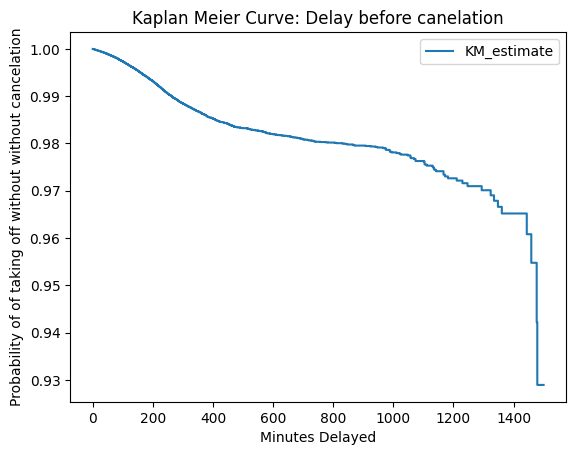

In [35]:
# Plot survival graph
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df_flight_data["DepDelayMinutes"],
    event_observed=df_flight_data["Cancelled"]
)

kmf.plot(ci_show=False)

plt.title("Kaplan Meier Curve: Delay before canelation")
plt.xlabel("Minutes Delayed")
plt.ylabel("Probability of of taking off without without cancelation")
plt.show()


In [40]:
cph = CoxPHFitter()

cph.fit(
    df_flight_data,
    duration_col="DepDelayMinutes",
    event_col="Cancelled",
    strata=["Operating_Airline"]
)

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 9.18398e+06 total observations, 9.17426e+06 right-censored observations>
             duration col = 'DepDelayMinutes'
                event col = 'Cancelled'
                   strata = Operating_Airline
      baseline estimation = breslow
   number of observations = 9.18398e+06
number of events observed = 9721
   partial log-likelihood = -107404.32
         time fit was run = 2026-02-17 02:07:57 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
DepTime          0.00      1.00      0.00            0.00            0.00                1.00                1.00
OriginAirportID -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
DistanceGroup   -0.04      0.96      0.01           -0.05           -0.03                0.95                0.97
Month           -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99
DayOfWeek        0.00      1.00      0.01           -0.01            0.01                0.99                1.01

                 cmp to     z      p  -log2(p)
covariate                                     
DepTime            0.00  8.11 <0.005     50.85
OriginAirportID    0.00 -2.76   0.01      7.42
DistanceGroup      0.00 -7.40 <0.005     42.79
Month              0.00 -5.28 <0.005     22.87
DayOfWeek          0.00  0.40   0.69      0.53
---
Concordance = 0.52
Partial AIC = 214818.64
log-likelihood ratio test = 166.77 on 5 df
-log2(p) of ll-ratio test = 111.11

,DepDelayMinutes,Cancelled,DepTime,Operating_Airline,OriginAirportID,DistanceGroup,Month,DayOfWeek
6,2.0,False,1204.0,9E,10146,1,1,1
9,24.0,False,1101.0,9E,10397,1,1,3
14,22.0,False,1059.0,9E,10397,1,1,1
15,105.0,False,1222.0,9E,10397,1,1,2
18,7.0,False,1044.0,9E,10397,1,1,5
...,...,...,...,...,...,...,...,...
29193776,154.0,False,2309.0,YX,11618,4,3,6
29193777,25.0,False,2014.0,YX,13495,5,3,4
29193778,44.0,True,1817.0,YX,11057,3,3,4
29193779,378.0,False,2318.0,YX,10257,3,3,2
